In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm.auto import tqdm

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

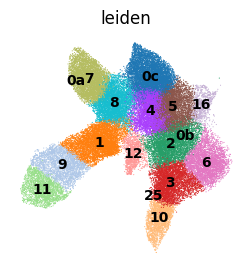

In [47]:
# load the truncated atlas : shape 49390, 4814
adata = sc.read_h5ad("data/tom_pos.h5ad")
raw_ad = adata.raw.to_adata()

mkery = sc.read_h5ad("data/mk_ery_DM_densityEst.h5ad")
MEP_cbs = np.intersect1d(adata.obs_names, mkery.obs_names)

# load PINN inferred params
# g: (9, 49390) , v: (9, 49390, 10)
# g = np.load("results/tom_pos-DM_scaled_n9/pde_params_tsense_Dec04_onbase/version_0_g.npy")
# v = np.load("results/tom_pos-DM_scaled_n9/pde_params_tsense_Dec04_onbase/version_0_v.npy")
g = np.load("results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense_Dec06_onbase/version_4_g.npy")/15
v = np.load("results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense_Dec06_onbase/version_4_v.npy")/15



fig=plt.figure(figsize=(3,3), dpi=100)
sc.pl.umap(adata, color='leiden', legend_loc='on data', frameon=False, ax=fig.gca())

In [3]:
celltype_pallete = {"HSC":"#E278C6","Meg":"#AFC7E5","Mono/DC prog":"#FFC58B",
 "Int prog":"#C8C8C8","Ery":"#8C554A","Eos":"#AD40FC",
 "Neu":"#9BDD91","Bas/MC prog":"#279F6A","Ly":"#31C6D3"}

# inspect params

In [4]:
v.shape

(9, 49390, 10)

In [116]:
dm_range = (adata.obsm['DM_scaled'][:,:10].max(axis=0,keepdims=True)- adata.obsm['DM_scaled'][:,:10].min(axis=0,keepdims=True))
for i,t in enumerate(adata.uns['pop']['t']):
    adata.obs[f'Day{t} g'] = g[i] 
    
    v_scaled_norm = np.sqrt(np.sum((v[i]/dm_range)**2, axis=1)) 
    adata.obs[f'Day{t} v norm'] = v_scaled_norm

In [44]:
# psdyn inferred params
cb_of_cluster = {}
param_df = []
for clu in [7,10,11]:
    param = pd.read_csv(f"data/HSCP_PD_params/clu{clu}/table_all_parameters_clu_{clu}.csv", index_col=0)
    param['leiden'] = str(clu)
    param_df.append(param)

    print(clu, param.shape)
    print(clu, np.intersect1d(adata.obs_names, param.index).shape)

    cb_of_cluster[str(clu)] = np.intersect1d(adata.obs_names, param.index)

param_df =  pd.concat(param_df)
param_df.head(3)

7 (8704, 7)
7 (8681,)
10 (19227, 7)
10 (19049,)
11 (16532, 7)
11 (16427,)


,dpt_pseudotime,dpt_pseudotime_scaled,diffusion,drift,dpt_pseudotime_scaled2,growth,leiden
9mo_SIGAE3_AAACCCAAGACCTCAT-1-10x,0.059012,0.578092,0.000114,0.097776,0.578354,-0.29758,7
9mo_SIGAE3_AAACGAATCTACGGTA-1-10x,0.057721,0.565515,0.000112,0.096416,0.565734,-0.25188,7
9mo_SIGAE3_AAACGCTTCCGTGCGA-1-10x,0.011457,0.114933,0.000061,0.016373,0.113636,0.11150,7


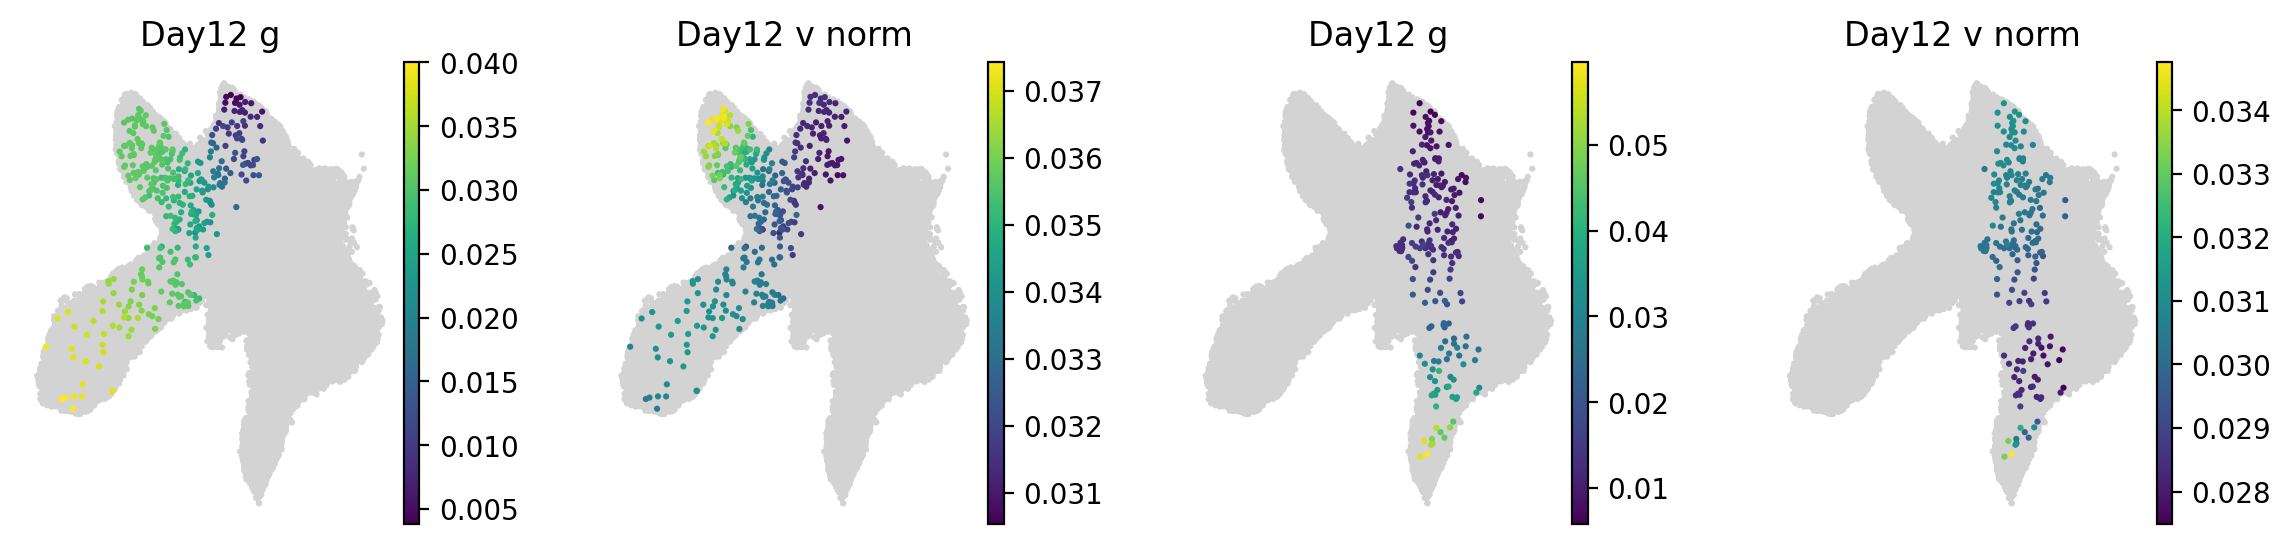

In [ ]:
day = 12#49 #161, 269
fig, axs = plt.subplots(1,4,figsize=(14,3), dpi=80, frameon=False, gridspec_kw={'wspace':0.4})
lineages = ['Meg/Ery','Neu']
cbs = [ MEP_cbs, cb_of_cluster['10']]

for i,cb in enumerate(cbs):
    clu = str(clu)
    clu_ad = adata[cb]f
    #vis
    
    sc.pl.umap(adata,  frameon=False, show=False, ax=axs[i*2], size=20)
    sc.pl.umap(adata,  frameon=False, show=False, ax=axs[i*2+1], size=20)

    sc.pl.umap(clu_ad[clu_ad.obs.timepoint_tx_days==day], color=f'Day{day} g', frameon=False, show=False, ax=axs[i*2], size=20)
    sc.pl.umap(clu_ad[clu_ad.obs.timepoint_tx_days==day], color=f'Day{day} v norm', frameon=False, show=False, ax=axs[i*2+1], size=20)

In [7]:
import matplotlib as mpl

In [ ]:
dpi = 600

for day in adata.uns['pop']['t']:
    
    lineages = ['Meg','Neu','Ery']
    for i,clu in enumerate([7,10,11]):
        
        fig = plt.figure(figsize=(6,3), dpi=dpi, frameon=False)
        plt.tight_layout(w_pad=0, h_pad=0)
        gs = mpl.gridspec.GridSpec(8, 10, left=0, right=1)
        axs = [fig.add_subplot(gs[1:,:4]), fig.add_subplot(gs[1:,5:-1])] 
        fig.suptitle(f" Day{day} {lineages[i]} lineage")

        clu = str(clu)
        clu_ad = adata[cb_of_cluster[str(clu)]]
        
        sc.pl.umap(adata,  frameon=False, show=False, ax=axs[0], size=20)
        sc.pl.umap(adata,  frameon=False, show=False, ax=axs[1], size=20)

        sc.pl.umap(clu_ad[clu_ad.obs.timepoint_tx_days==day], color=f'Day{day} g', frameon=False, show=False, ax=axs[0], size=20, title=f'  growth rate')
        sc.pl.umap(clu_ad[clu_ad.obs.timepoint_tx_days==day], color=f'Day{day} v norm', frameon=False, show=False, ax=axs[1], size=20, title=f'diff. rate')
        

        if dpi==600:
            fig.savefig(f"figures/tompos_3_lineage_params/Day{day}_{lineages[i]}.pdf", format='pdf', transparent=True)
        
        # fig.show(False)

In [ ]:
dpi = 60
fig = plt.figure(figsize=(6,3), dpi=dpi, frameon=False)
plt.tight_layout(w_pad=0, h_pad=0)
gs = mpl.gridspec.GridSpec(8, 10, left=0, right=1)
axs = [fig.add_subplot(gs[1:,:4]), fig.add_subplot(gs[1:,5:-1])] 
fig.suptitle(f" ")
sc.pl.umap(adata, color='Vwf',  legend_loc='on data', frameon=False, ax=axs[0], show=False)
sc.pl.umap(adata, color='Pf4',  legend_loc='on data', frameon=False, ax=axs[1], show=False)
if dpi==600:
    fig.savefig(f"figures/Vwf_Pf4_expression.pdf" , format='pdf', transparent=True)

# change by time

In [8]:
agg_param_t = []
g_dfs = []
v_dfs = []

clu_ad = adata[adata.obs.query("`anno_man` != 'Eos'").index]

for t in clu_ad.uns['pop']['t']:
    # param of time
    param_df = clu_ad.obs.query("`timepoint_tx_days` == @t")

    ct_count_dict = param_df.groupby(["anno_man"]).agg({"biosample_id":'count'}).to_dict()['biosample_id']
    param_df['n_cell_ct'] = param_df['anno_man'].map(ct_count_dict).values
    
    g_dfs.append(
        param_df[[f'Day{t} g','anno_man','timepoint_tx_days','n_cell_ct']].rename({f'Day{t} g':'g'}, axis=1)
    )

    v_dfs.append(
        param_df[[f'Day{t} v norm','anno_man','timepoint_tx_days','n_cell_ct']].rename({f'Day{t} v norm':'v'}, axis=1)
    )

    param_df_by_ct = param_df[[f'Day{t} g', f'Day{t} v norm','anno_man']
                              ].groupby("anno_man").agg("mean")
    agg_param_t.append(param_df_by_ct)

agg_param_df = pd.concat(agg_param_t, axis=1)

g_df = pd.concat(g_dfs).astype({'timepoint_tx_days':'str'}).query("`n_cell_ct` > 15")
v_df = pd.concat(v_dfs).astype({'timepoint_tx_days':'str'}).query("`n_cell_ct` > 15")

/tmp/ipykernel_2363381/3219240590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  param_df['n_cell_ct'] = param_df['anno_man'].map(ct_count_dict).values
/tmp/ipykernel_2363381/3219240590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  param_df['n_cell_ct'] = param_df['anno_man'].map(ct_count_dict).values
/tmp/ipykernel_2363381/3219240590.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [9]:
import seaborn as sns

<Axes: xlabel='timepoint_tx_days', ylabel='v'>

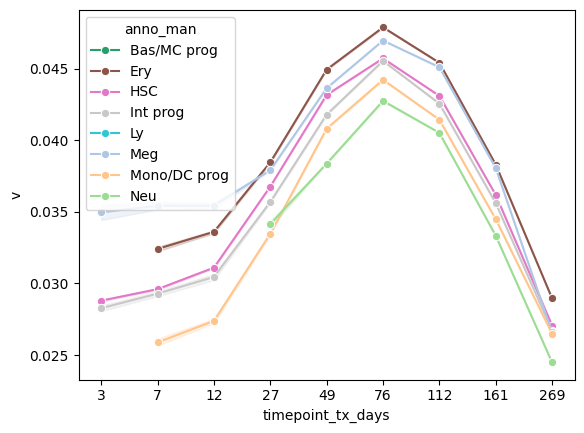

In [10]:
ct_of_interest = ['HSC', 'Int prog','Ery', 'Meg', 'Neu', 'Mono/DC prog']
sns.lineplot(data=v_df.query("`anno_man` in @ct_of_interest"),
              x='timepoint_tx_days', y='v', marker='o',
             hue='anno_man', palette=celltype_pallete)

# predicting continous growth params

In [4]:
import PINN
import seaborn as sns

In [5]:
device = 'cuda:2'

In [6]:
DS_full = reader.TwoTimpepoint_AnnDS(AnnData=adata, timepoint_idx=None,  
                            n_dimension = 10,
                              cellstate_key='DM_scaled',  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              batchsize=100)

Computing density :
`density_funs` not specified, use gaussian kde


In [10]:
DS_full.T_b

array([ 1.        ,  2.33333333,  4.        ,  9.        , 16.33333333,
       25.33333333, 37.33333333, 53.66666667, 89.66666667])

In [11]:
model_ckpt = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=95-total_loss=1.33532071.ckpt"
# model_ckpt = "logs/tompos_leavout_t5n7/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=26-total_loss=6.62615013.ckpt"
# model_ckpt = "logs/tompos_leavout_t5n7/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=28-total_loss=6.15941000.ckpt"
# model_ckpt = "logs/tompos_leavout_t5n7/pde_params_tsense/lightning_logs/version_2/checkpoints/epoch=122-total_loss=5.13009357.ckpt"
# model_ckpt = "logs/tompos_leavout_t5n7/pde_params_tsense/lightning_logs/version_3/checkpoints/epoch=119-total_loss=2.68412280.ckpt"
model = PINN.models.pde_params.load_from_checkpoint(model_ckpt)
pde_model = model.to(device)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [12]:
g, v, D = pde_model.predict_param(DS_full)

In [13]:
@torch.no_grad
def continuous_params(pde_model, DataSet, 
                        param = 'g',
                        chunk_size = 1000,
                        groupby_key = None,
                        n_interval = 10,
                        agg_fun = 'mean'):

    param_ls = []

    # <ForLoop1: iterate between timepoint and obsreved cellstate>
    for it, s_ts in tqdm(enumerate(DataSet.cellstate_t_ls[:-1])):
        t = DataSet.T_b[it]
        tp1 = DataSet.T_b[it+1]

        # print("from" , t, "to",tp1)

        if groupby_key is not None:
            agg_col = []
            real_time = DataSet.popD['t'][it]
            # obs_t = DataSet.adata.obs.query(f"`{DataSet.timepoint_key}` == @real_time").copy()
            obs_t = DataSet.adata.obs.copy()
            obs_t['str_col'] = 'x'
            ct_count_dict = obs_t.query(f"`{DataSet.timepoint_key}` == @real_time").groupby([groupby_key]).agg({"str_col":'count'}).to_dict()['str_col']
        
        # <ForLoop2:iterate with differrent intemediate t>
        if it+1 == len(DataSet.cellstate_t_ls[:-1]):
            int_timepoint = np.linspace(t, tp1, n_interval+1)
        else:
            int_timepoint = np.linspace(t, tp1, n_interval+1)[:-1]
        for t_mid in int_timepoint:

            s_ts_gpu = torch.from_numpy(DataSet.cellstate).float().to(device)
            t_ts = torch.full((s_ts_gpu.shape[0],), t_mid).float().to(device)

            # <ForLoop3:forward by chunk>
            param_t = []
            for i in range(0, len(t_ts), chunk_size):                              
                s_in = s_ts_gpu[i:i+chunk_size]
                t_in = t_ts[i:i+chunk_size]

                # forward here
                param_pred = pde_model.__getattr__(param)(s_in, t_in) / pde_model.time_scale_factor
                param_t.append(param_pred.detach().cpu().numpy())
            
            param_catchunk = np.concatenate(param_t, axis=0)
            # <ForLoop3>

            if groupby_key is not None:
                obs_t[f"{np.around(t_mid*3, 2)}"] = param_catchunk
                agg_col.append(f"{np.around(t_mid*3, 2)}")
            else:
                param_ls.append(param_catchunk)
            # <ForLoop2>

        if groupby_key is not None:
            params = obs_t[agg_col+[groupby_key]].groupby(groupby_key).agg(agg_fun)
            params = pd.melt(params.reset_index(), id_vars=groupby_key, value_name=param)
            params['timepoint_tx_day'] = real_time
            params['ct_of_day'] = params[groupby_key].map(ct_count_dict)
            param_ls.append(params)
        # <ForLoop1>

    return param_ls

In [14]:
grouped_params = continuous_params(pde_model, DS_full, groupby_key='fine_anno')

0it [00:00, ?it/s]

In [15]:
grouped_param = pd.concat(grouped_params, axis=0)
grouped_param['g'] = grouped_param['g'].values /3
grouped_param = grouped_param.query("`ct_of_day` > 10")

In [16]:
grouped_param.head()

,fine_anno,variable,g,timepoint_tx_day,ct_of_day
0,HSC,3.0,0.008143,3,138
1,Int prog,3.0,0.019985,3,158
2,Meg/Ery prog,3.0,0.039158,3,41
3,Meg prog,3.0,0.052271,3,29
7,Mono/DC prog,3.0,0.014060,3,11


In [17]:
grouped_param.query("`fine_anno` == 'HSC'")['variable'].nunique()

81

In [18]:
intermediate_time = grouped_param.query("`fine_anno` == 'HSC'")['variable'].astype(float).values[np.arange(0,80,5)]
intermediate_time = (intermediate_time*3).astype(int)

In [19]:
intermediate_time

array([  9,  15,  21,  28,  36,  58,  81, 114, 147, 187, 228, 282, 336,
       409, 483, 645])

In [24]:
grouped_param.to_csv("results/tompos_continuous_growth_dataframe.csv", index=False)

In [28]:
grouped_param['variable'] = grouped_param.variable.astype(float)

/tmp/ipykernel_2404399/678438943.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend(frameon=False)


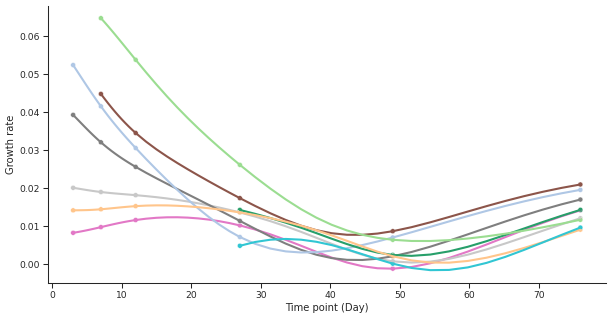

In [64]:

dpi=60

celltype_pallete = dict(zip(adata.obs['fine_anno'].cat.categories, adata.uns['fine_anno_colors']))

all_int_time = grouped_param['variable'].unique()
intermediate_time = all_int_time.astype(float)[np.arange(0,81,5)]
obs_T = all_int_time[np.arange(0,81,10)]

grouped_param_shorter = grouped_param.query('`variable` <= 76')

fig = plt.figure(dpi=dpi, figsize=(12,6), frameon=True)
fig.tight_layout(rect=[-0.5,-0.6,1.05,1])
ax = plt.gca()
g = sns.lineplot(data=grouped_param_shorter, x='variable', y='g', 
                 hue='fine_anno', palette=celltype_pallete,
                 ax=ax, linewidth=2.5,  legend=False,
                 )
sns.scatterplot(data=grouped_param_shorter.query('`variable` in @obs_T'), x='variable', y='g', 
                 hue='fine_anno', palette=celltype_pallete,
                 marker='o', legend=False,
                 ax=ax
                 )
g.legend(frameon=False)
sns.despine(ax=g)
g.set_ylabel("Growth rate", fontsize=12)
g.set_xlabel("Time point (Day)", fontsize=12)
# g.set_xticks(np.arange(0,81,5))
# g.set_xticklabels(intermediate_time, rotation=40);


if dpi==600:
    fig.savefig('figures/tompos_continous_growth_<Day76.pdf', format='pdf', 
                transparent=True)

In [69]:
min_time_dict = {}
for ct in adata.obs['fine_anno'].cat.categories:

    if ct == 'Eos prog':
        continue

    ct_df = grouped_param.query("`fine_anno`==@ct")
    min_time = ct_df['variable'].values[ct_df['g'].argmin()]

    min_time_dict[ct] = min_time

In [70]:
min_growth_day = pd.json_normalize([min_time_dict]).T.reset_index()
min_growth_day.columns = ['fine_anno',  'min_g_day']

In [71]:
min_growth_day = min_growth_day.sort_values("min_g_day")

In [72]:
min_growth_day['min_g_day'] = min_growth_day['min_g_day'].astype(float)

/tmp/ipykernel_2404399/3081859473.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=min_growth_day, y='fine_anno', x='min_g_day',


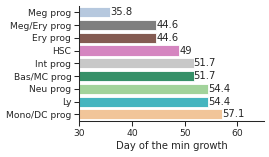

In [73]:
dpi=60
fig= plt.figure(figsize=(5,3), dpi=dpi, frameon=False)
# gs = plt.gridspec.GridSpec(6,5)
gs = fig.add_gridspec(nrows=6, ncols=5)
ax = fig.add_subplot(gs[:5,1:])


sns.barplot(data=min_growth_day, y='fine_anno', x='min_g_day', 
            orient='h', ax=ax, palette=celltype_pallete)
for value in ax.containers:
    ax.bar_label(value) 
ax.set_ylabel("")
sns.despine(ax=ax)
ax.set_xlabel("Day of the min growth")
ax.set_xlim(30,65)

if dpi == 600:
    fig.savefig('figures/tompos_growth_minday.pdf', format='pdf', 
                    transparent=True)

In [303]:
ax.get_xlim(),ax.get_ylim()

((0.0, 5.25), (8.5, -0.5))

# Meg growth by dpt

In [39]:
s = torch.from_numpy(DS_full.cellstate).float().to(device)
t = torch.from_numpy(adata.obs['timepoint_tx_days'].values).float().to(device) /3

In [40]:
with torch.no_grad():
    adata.obs['g_inpoint'] = pde_model.g(s,t).cpu().numpy()

In [41]:
gdf = adata.obs[['timepoint_tx_days','dpt_pseudotime','g_inpoint']]
gdf['timepoint'] = gdf['timepoint_tx_days'].astype(str)

/tmp/ipykernel_2404399/1494305632.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf['timepoint'] = gdf['timepoint_tx_days'].astype(str)


In [42]:

def aggregate_params_by_pseudotime(params, param_names='g', timepoints=None, adata=adata, pseudotime_key='pseudotime_scaled',nbins=100, return_y=True):
    

    pdt_bins = np.linspace(0, adata.obs[pseudotime_key].max(), nbins+1)
    pdt_label = (pdt_bins[1:] + pdt_bins[:-1])/2
    adata.obs['pseudotime_bin'] = pd.cut(adata.obs[pseudotime_key], bins=nbins,
                                                labels = pdt_label)


    timepoints = adata.uns['pop']['t'] if timepoints is None else timepoints 
    fig, axs = plt.subplots(1, len(timepoints), figsize=(4*len(timepoints)+1,3), gridspec_kw={"wspace":0.4, 'hspace':0.3})
    axs = axs.flatten() if len(timepoints)>1 else [axs]
    
    y_smooths = []
    for i,t in enumerate(timepoints):
        y_col = 'Day%s_'%t + param_names
        data = adata.obs[['pseudotime_bin']]
        data[y_col] = params[i]
        gdata = data.groupby("pseudotime_bin").agg({y_col:"mean"}).reset_index()

        x = np.sort(gdata.pseudotime_bin.unique())
        y = gdata[y_col].values

        model2 = np.poly1d(np.polyfit(x, gdata[y_col], 7))

        x_smooth = (x[1:] + x[:-1] )/2
        y_smooth = (y[1:] + y[:-1] )/2

        axs[i].scatter(x_smooth, y_smooth, alpha=0.8)
        axs[i].plot(x, model2(x), color='red', alpha=0.4)

        y_smooths.append(y_smooth)

    if return_y:
        return y_smooths
    else:
        return fig, axs

In [48]:
clu_7_mask = [np.where(adata.obs_names==cb)[0].item() for cb in cb_of_cluster['7']]
clu_7_ad = adata[cb_of_cluster['7']]

g_clu7 = np.stack([g_i[clu_7_mask] for g_i in g])
clu_7_ad.obs['g_t3'] = g_clu7[0]

print(g_clu7.shape)
clu_7_ad

/tmp/ipykernel_2404399/2429813759.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  clu_7_ad.obs['g_t3'] = g_clu7[0]


(9, 8681)


AnnData object with n_obs × n_vars = 8681 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

In [49]:
dpt = clu_7_ad.obs['dpt_pseudotime'].values
dpt_range = dpt.max() - dpt.min()

clu_7_ad.obs['scaled pseudotime'] = dpt/dpt_range

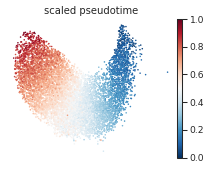

In [268]:
fig, ax = plt.subplots(figsize=(4,3), dpi=60, frameon=False)

sc.pl.umap(clu_7_ad, color='scaled pseudotime', ax=ax, 
           frameon=False, title='scaled pseudotime', cmap='RdBu_r')

# fig.savefig("figures/tompos_Meg_dpt.pdf", format='pdf', transparent=True)

In [50]:
def smooth_with_knot(y, nbins):
    x_upper = clu_7_ad.obs['dpt_pseudotime'].max()
    x_knots = torch.linspace(0, x_upper,nbins)
    y_knots = torch.from_numpy(y)

    g_cs = PINN.models.CubicSpline(x=x_knots, y=y_knots)

    g_smooth = g_cs(torch.linspace(0,x_upper,300),None).detach().numpy()
    g_smooth = (g_smooth[:-1] + g_smooth[1:])/2
    return g_smooth

/tmp/ipykernel_2404399/1730205188.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[y_col] = params[i]
/tmp/ipykernel_2404399/1730205188.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[y_col] = params[i]
/tmp/ipykernel_2404399/1730205188.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

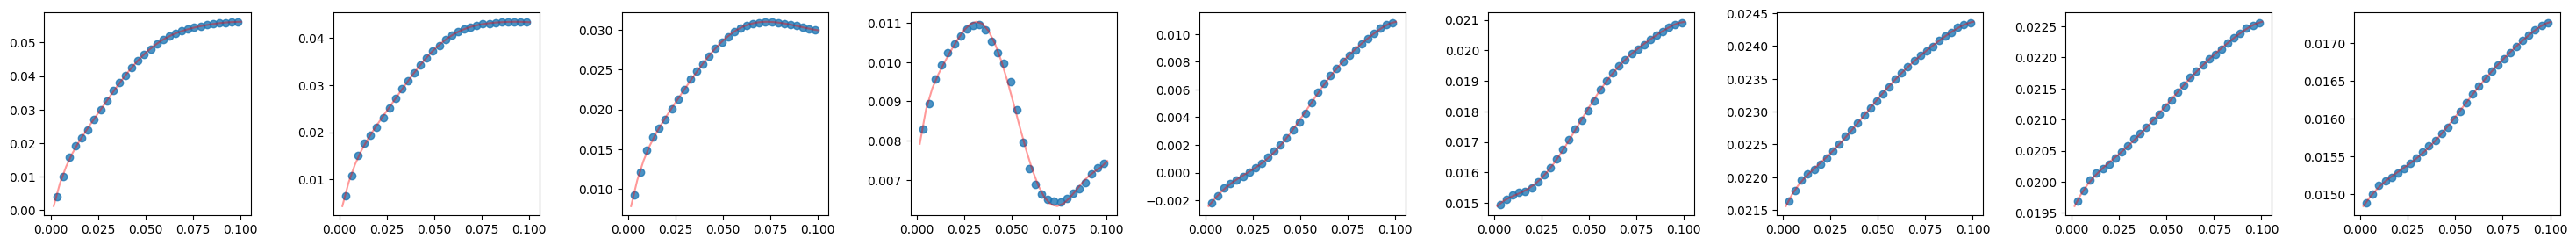

In [51]:
nbins = 30
ys =  aggregate_params_by_pseudotime(g_clu7, param_names='g',
                                   timepoints=adata.uns['pop']['t'],
                                    pseudotime_key='dpt_pseudotime', 
                                    adata=clu_7_ad, 
                                    nbins=nbins+1, return_y=True)

g_smooths = [smooth_with_knot(y, nbins) for y in ys]

In [52]:
g_smooths[0].shape

(299,)

In [53]:
colors= sns.color_palette(n_colors=9)
# colors = sns.light_palette((20, 60, 50), input="husl", n_colors=9)

In [54]:
clu_7_ad.obs.groupby(['fine_anno']).agg(
    {"dpt_pseudotime":['min', 'median',lambda x: np.quantile(x, 0.95)]}
    )

dpt_pseudotime                     
                        min    median <lambda_0>
fine_anno                                       
HSC                0.000000  0.012137   0.021917
Meg/Ery prog       0.015791  0.041334   0.051763
Meg prog           0.033396  0.065231   0.085799

Text(0.5, 0, 'scaled pseudotime')

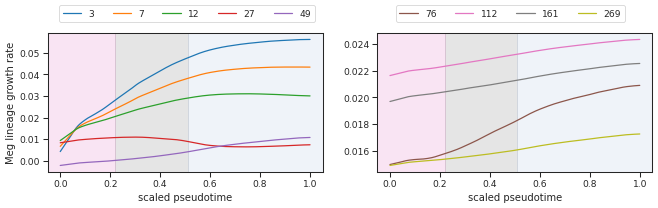

In [63]:
sns.set_theme(style="ticks", font_scale=1)

fig, axs = plt.subplots(1,2, figsize=(13,3), dpi=60, frameon=False, gridspec_kw={"wspace":0.2})

ax1, ax2 = axs

x = np.linspace(0,1,299)

for i in range(5):
    ax1.plot(x, g_smooths[i], color=colors[i], label=clu_7_ad.uns['pop']['t'][i])
    ax1.legend(ncol=5, bbox_to_anchor=[0.025,1.05])

ax1.axvspan(ax1.get_xlim()[0], 0.22, alpha=0.2, color=celltype_pallete['HSC'])
ax1.axvspan(0.22, 0.51, alpha=0.2, color=celltype_pallete['Meg/Ery prog'])
ax1.axvspan(0.51, ax1.get_xlim()[1], alpha=0.2, color=celltype_pallete['Meg prog'])
ax1.set_xlim(-0.05,1.05)

ax1.set_xlabel('scaled pseudotime')
ax1.set_ylabel('Meg lineage growth rate')

for i in range(5,9):
    ax2.plot(x, g_smooths[i], color=colors[i], label=clu_7_ad.uns['pop']['t'][i])
    ax2.legend(ncol=5, bbox_to_anchor=[0.05,1.05])

ax2.axvspan(ax2.get_xlim()[0], 0.22, alpha=0.2, color=celltype_pallete['HSC'])
ax2.axvspan(0.22, 0.51, alpha=0.2, color=celltype_pallete['Meg/Ery prog'])
ax2.axvspan(0.51, ax2.get_xlim()[1], alpha=0.2, color=celltype_pallete['Meg prog'])
ax2.set_xlim(-0.05,1.05)

ax2.set_xlabel('scaled pseudotime')
# ax2.set_ylabel('growth rate')


In [56]:
fig.savefig("figures/fig4_meg_pdt_growth.pdf", transparent=True)